# Brewster angle incidence (JAX)

This notebook reproduces the Brewster-angle scenario using the JAX-based
tropospheric propagator. A vertically polarized Gaussian beam is launched
toward a finite-permittivity ground at the Brewster angle, where the
Fresnel reflection coefficient vanishes. The lower nonlocal boundary
condition (NLBC) of the JAX propagator is configured from the ground
material via `TroposphereModel.ground_material`.

For the legacy NumPy/Cython version, see [brewster_angle.ipynb](brewster_angle.ipynb).

In [1]:
import os, sys
for p in [".", "..", "../..", "../../..", "../../../.."]:
    full = os.path.abspath(p)
    if os.path.exists(os.path.join(full, "pywaveprop")):
        sys.path.insert(0, full)
        break

In [2]:
import jax
jax.config.update('jax_enable_x64', True)

import cmath as cm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from pywaveprop.rwp_jax import (
    RWPGaussSourceModel,
    RWPComputationalParams,
    TroposphereModel,
    GroundMaterial,
    rwp_forward_task,
)
from pywaveprop.propagators._utils import brewster_angle

# Legacy two-ray reference
from pywaveprop.rwp.antennas import GaussAntenna
from pywaveprop.rwp.environment import Troposphere, Terrain, CustomMaterial
from pywaveprop.rwp.tworay import TwoRayModel

## Preparing environment

Flat troposphere with a finite-permittivity ground (eps=3, sigma=0). The
`ground_material` field on `TroposphereModel` enables the angle-dependent
lower NLBC inside the JAX propagator.

In [3]:
ground_material = GroundMaterial(eps=3, sigma=0)
env = TroposphereModel(
    M0=320,
    slope=0.0,  # flat earth
    ground_material=ground_material,
)

## Preparing transmitting antenna

A vertically polarized 3 GHz Gaussian beam tilted downward at the
Brewster angle of the air/ground interface.

In [4]:
freq_hz = 3000e6
b_angle = brewster_angle(1, ground_material.complex_permittivity(freq_hz)).real
print(f'Brewster angle = {b_angle:.3f} deg (from surface normal)')

src = RWPGaussSourceModel(
    freq_hz=freq_hz,
    height_m=50,
    beam_width_deg=5,
    elevation_angle_deg=90 - b_angle,  # positive = downward toward ground
    polarization='V',
)

# Range chosen so that the specular reflection point sits inside the domain
h1 = src.height_m
a = abs(h1 / cm.tan(abs(src.elevation_angle_deg) * cm.pi / 180))
max_range_m = 2 * a + 200
print(f'max_range_m = {max_range_m:.1f}')

Brewster angle = 60.000 deg (from surface normal)
max_range_m = 373.2


## Computational parameters and forward task

In [5]:
params = RWPComputationalParams(
    max_range_m=max_range_m,
    max_height_m=100,
    max_angle_deg=abs(src.beam_width_deg) + abs(src.elevation_angle_deg) + 5,
    dx_m=2.0,
    dz_m=0.05,
    precision=1e-3,
)

field_jax = rwp_forward_task(src, env, params)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


k_min: 62.85195926477884, k_max: 62.85195926477884
rational_approx_order: (7, 8), beta: 54.039408608699915, dx: 0.5, dz: 0.0010204081632653062


## Reference solution: two-ray model

In [6]:
legacy_env = Troposphere(flat=True)
legacy_env.z_max = 100
legacy_env.terrain = Terrain(ground_material=CustomMaterial(eps=3, sigma=0))

legacy_antenna = GaussAntenna(
    freq_hz=freq_hz,
    height=src.height_m,
    beam_width=src.beam_width_deg,
    elevation_angle=src.elevation_angle_deg,  # both conventions: positive = downward
    polarz='V',
)

trm = TwoRayModel(src=legacy_antenna, env=legacy_env)
trm_x = np.linspace(1, max_range_m, 2000)
trm_z = np.linspace(1, legacy_env.z_max, 400)
trm_f = trm.calculate(trm_x, trm_z)

## Visualisation

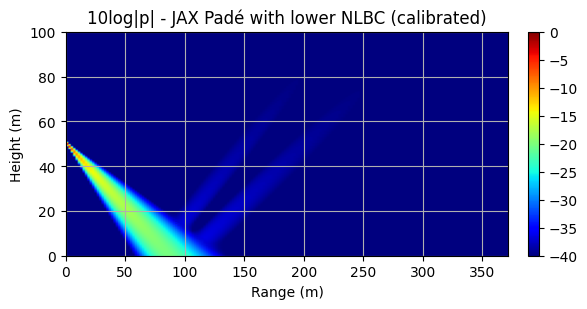

In [7]:
def plot_field_2d(x_grid, z_grid, data, title='', vmin=-40, vmax=0):
    extent = [x_grid[0], x_grid[-1], z_grid[0], z_grid[-1]]
    plt.figure(figsize=(6, 3.2))
    plt.imshow(data.T[::-1, :], extent=extent, norm=Normalize(vmin, vmax),
               aspect='auto', cmap='jet')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xlabel('Range (m)')
    plt.ylabel('Height (m)')
    plt.tight_layout()
    plt.grid(True)
    plt.show()

jax_x = np.asarray(field_jax.x_grid)
jax_z = np.asarray(field_jax.z_grid)
jax_n_x = min(field_jax.field.shape[0], jax_x.shape[0])
jax_n_z = min(field_jax.field.shape[1], jax_z.shape[0])

# PE reduced field → physical field: p(x,z) = u(x,z) · √(2π / (k₀ x))
k0 = 2 * np.pi * freq_hz / 3e8
jax_phys = np.asarray(field_jax.field[:jax_n_x, :jax_n_z]) * np.sqrt(
    2 * np.pi / (k0 * np.maximum(jax_x[:jax_n_x], 1.0))
)[:, np.newaxis]
jax_data = 10 * np.log10(np.abs(jax_phys) + 1e-16)

plot_field_2d(jax_x[:jax_n_x], jax_z[:jax_n_z], jax_data,
              title='10log|p| - JAX Padé with lower NLBC (calibrated)')

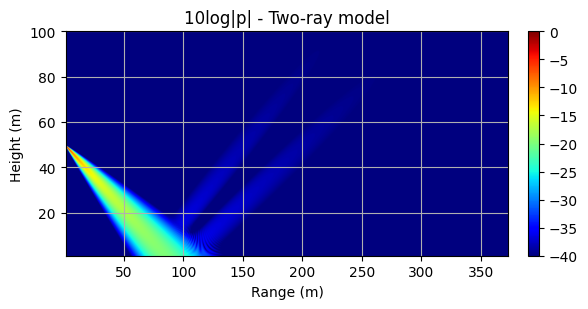

In [8]:
trm_data = 10 * np.log10(np.abs(trm_f) + 1e-16)
plot_field_2d(trm_x, trm_z, trm_data, title='10log|p| - Two-ray model')

### Horizontal slice near the ground

The beam path crosses z = 10 m close to the ground-bounce point.
At the Brewster angle the V-polarized reflection coefficient vanishes,
so the interference pattern between direct and reflected rays
collapses and only the direct field remains.

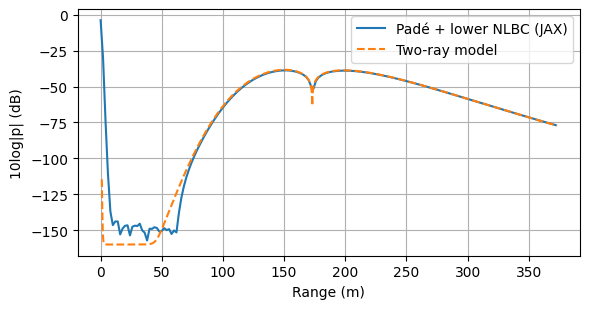

In [9]:
z0 = 50  # near-ground slice where the direct beam passes

z_idx_jax = int(np.argmin(np.abs(jax_z[:jax_n_z] - z0)))
# Use calibrated physical field
jax_slice = 10 * np.log10(np.abs(jax_phys[:, z_idx_jax]) + 1e-16)

z_idx_trm = int(np.argmin(np.abs(trm_z - z0)))
trm_slice = 10 * np.log10(np.abs(trm_f[:, z_idx_trm]) + 1e-16)

plt.figure(figsize=(6, 3.2))
plt.plot(jax_x[:jax_n_x], jax_slice, label='Padé + lower NLBC (JAX)')
plt.plot(trm_x, trm_slice, '--', label='Two-ray model')
plt.xlabel('Range (m)')
plt.ylabel('10log|p| (dB)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()